<a href="https://colab.research.google.com/github/ValleyFarell/FlowMatching-And-Diffusion-Models-from-scratch/blob/main/FlowMatchingAndDiffusionModels_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import sklearn
import tqdm

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch:", torch.__version__)
print("Device:", device)

if device.type == "cuda":
    props = torch.cuda.get_device_properties(0)
    print("GPU:", props.name)
    print(f"Videomemory: {props.total_memory / 1024**3:.1f} ГиБ")

PyTorch: 2.11.0+cu128
Device: cuda
GPU: Tesla T4
Videomemory: 14.6 ГиБ


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.datasets import make_moons

SEED = 42

np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_raw, _ = make_moons(
    n_samples=20_000,
    noise=0.05,
    random_state=SEED,
)


mean = train_raw.mean(axis=0, keepdims=True)
std = train_raw.std(axis=0, keepdims=True)

train_np = ((train_raw - mean) / std).astype(np.float32)

train_data = torch.from_numpy(train_np).to(device)

print("Train:", train_data.shape)

Train: torch.Size([20000, 2])


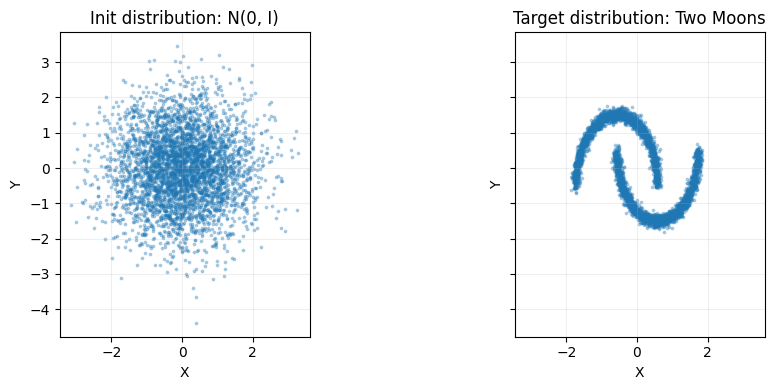

In [ ]:
rng = np.random.default_rng(SEED)

initial_noise = rng.standard_normal((4_000, 2)).astype(np.float32)
target_points = train_np[:4_000]

fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 4),
    sharex=True,
    sharey=True,
)

axes[0].scatter(
    initial_noise[:, 0],
    initial_noise[:, 1],
    s=3,
    alpha=0.3,
)
axes[0].set_title("Init distribution: N(0, I)")

axes[1].scatter(
    target_points[:, 0],
    target_points[:, 1],
    s=3,
    alpha=0.3,
)
axes[1].set_title("Target distribution: Two Moons")

for ax in axes:
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

In [ ]:
from torch import nn
import torch.optim as optim

class FMNeuralNetwork(nn.Module):
  def __init__(self):
    super().__init__()

    self.linear_1 = nn.Linear(3, 128)
    self.silu_1 = nn.SiLU()
    self.linear_2 = nn.Linear(128, 128)
    self.silu_2 = nn.SiLU()
    self.linear_3 = nn.Linear(128, 128)
    self.silu_3 = nn.SiLU()
    self.linear_4 = nn.Linear(128, 2)

  def forward(self, x):
    x = self.linear_1(x)
    x = self.silu_1(x)
    x = self.linear_2(x)
    x = self.silu_2(x)
    x = self.linear_3(x)
    x = self.silu_3(x)
    x = self.linear_4(x)

    return x


class FMModel():
  def __init__(self, NN, dim, dataset, verbose=True, log_every=50):
    self.NN = NN
    self.dim = dim
    self.dataset = dataset
    self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  def fit(self, epochs, batch_size, learning_rate=0.001, ):

    self.NN.to(self.device)

    train_loader = torch.utils.data.DataLoader(self.dataset, batch_size=batch_size, shuffle=True)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(self.NN.parameters(), lr=learning_rate)

    history = []
    for epoch in range(epochs):
      self.NN.train()
      running_loss = 0.0
      seen_samples = 0

      for inputs in train_loader:
        inputs = inputs.to(self.device)
        current_batch_size = inputs.shape[0]

        optimizer.zero_grad(set_to_none=True)
        epsilons = torch.randn(current_batch_size, self.dim, device=self.device)
        t = torch.rand(current_batch_size, 1, device=self.device)
        z = inputs
        x = t * z + (1 - t) * epsilons
        u = self.NN(torch.cat([x, t], dim=1))
        loss = criterion(u, z - epsilons)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * current_batch_size
        seen_samples += current_batch_size

      epoch_loss = running_loss / seen_samples
      history.append(epoch_loss)
      print(
        f"Epoch {epoch + 1}/{epochs}, "
        f"loss: {epoch_loss:.6f}"
      )

    return history

  @torch.no_grad()
  def sample(self, steps, n_samples=1):
    if steps < 1 or n_samples < 1:
      raise ValueError("steps and n_samples must be positive.")

    self.NN.to(self.device)
    self.NN.eval()

    dtype = next(self.NN.parameters()).dtype
    x = torch.randn(n_samples, self.dim, device=self.device, dtype=dtype)
    h = 1.0 / steps
    for i in range(steps):
      t = torch.full((n_samples, 1), i * h, device=self.device, dtype=dtype)
      x = x + h * self.NN(torch.cat([x, t], dim=1))
    return x

In [ ]:
u = FMNeuralNetwork()

model = FMModel(u, 2, train_data)
model.fit(100, 256)

Epoch 1/100, loss: 1.835037
Epoch 2/100, loss: 1.559045
Epoch 3/100, loss: 1.509615
Epoch 4/100, loss: 1.509843
Epoch 5/100, loss: 1.493758
Epoch 6/100, loss: 1.482757
Epoch 7/100, loss: 1.480873
Epoch 8/100, loss: 1.467148
Epoch 9/100, loss: 1.484619
Epoch 10/100, loss: 1.467759
Epoch 11/100, loss: 1.490663
Epoch 12/100, loss: 1.459651
Epoch 13/100, loss: 1.452060
Epoch 14/100, loss: 1.487056
Epoch 15/100, loss: 1.457073
Epoch 16/100, loss: 1.462728
Epoch 17/100, loss: 1.478249
Epoch 18/100, loss: 1.463063
Epoch 19/100, loss: 1.474969
Epoch 20/100, loss: 1.466100
Epoch 21/100, loss: 1.450354
Epoch 22/100, loss: 1.460778
Epoch 23/100, loss: 1.444651
Epoch 24/100, loss: 1.451654
Epoch 25/100, loss: 1.455438
Epoch 26/100, loss: 1.464224
Epoch 27/100, loss: 1.449990
Epoch 28/100, loss: 1.460833
Epoch 29/100, loss: 1.455996
Epoch 30/100, loss: 1.456124
Epoch 31/100, loss: 1.440803
Epoch 32/100, loss: 1.437320
Epoch 33/100, loss: 1.448214
Epoch 34/100, loss: 1.457919
Epoch 35/100, loss: 1.4

[1.8350372812271118,
 1.5590450660705566,
 1.5096148370742797,
 1.5098426710128785,
 1.4937576051712036,
 1.482757314491272,
 1.480873007583618,
 1.4671478610992432,
 1.484619006729126,
 1.4677585472106933,
 1.4906625667572022,
 1.4596510457992553,
 1.4520596733093263,
 1.4870555492401123,
 1.457073303604126,
 1.4627280639648437,
 1.4782493972778321,
 1.463062612438202,
 1.4749685995101929,
 1.466100159072876,
 1.450353537940979,
 1.4607780252456666,
 1.4446505855560303,
 1.451654083442688,
 1.4554376821517945,
 1.464223969078064,
 1.4499897373199462,
 1.4608332107543944,
 1.455996102142334,
 1.4561240203857422,
 1.4408031324386597,
 1.4373204830169677,
 1.4482136695861816,
 1.4579194492340088,
 1.4375636491775512,
 1.4324124343872071,
 1.431009449005127,
 1.4368896278381347,
 1.451257120513916,
 1.436844162940979,
 1.4233890043258668,
 1.4167003696441651,
 1.4086742715835572,
 1.4219794288635255,
 1.431603083229065,
 1.4138599658966065,
 1.4242009628295897,
 1.4046709705352782,
 1.412

### Some vibe coding ;)

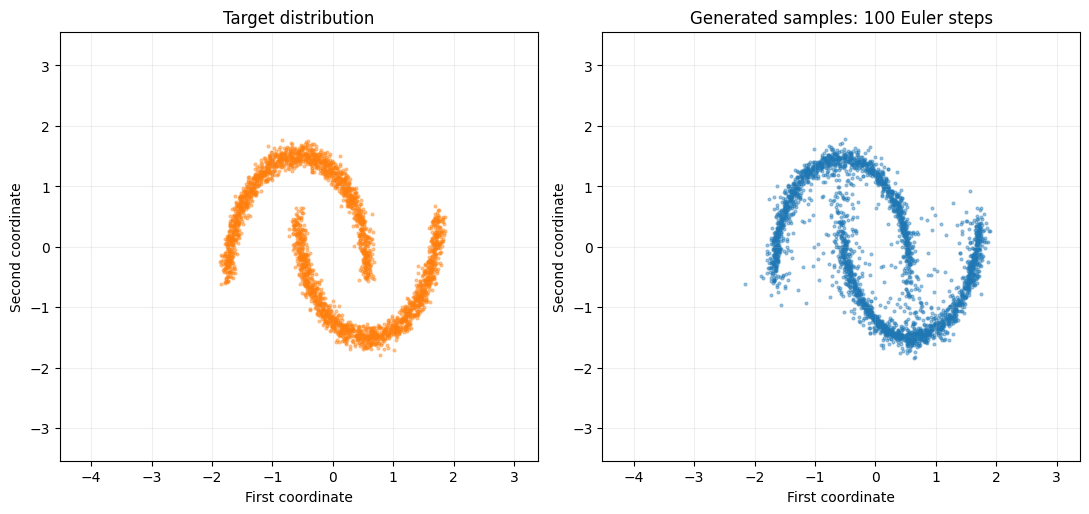

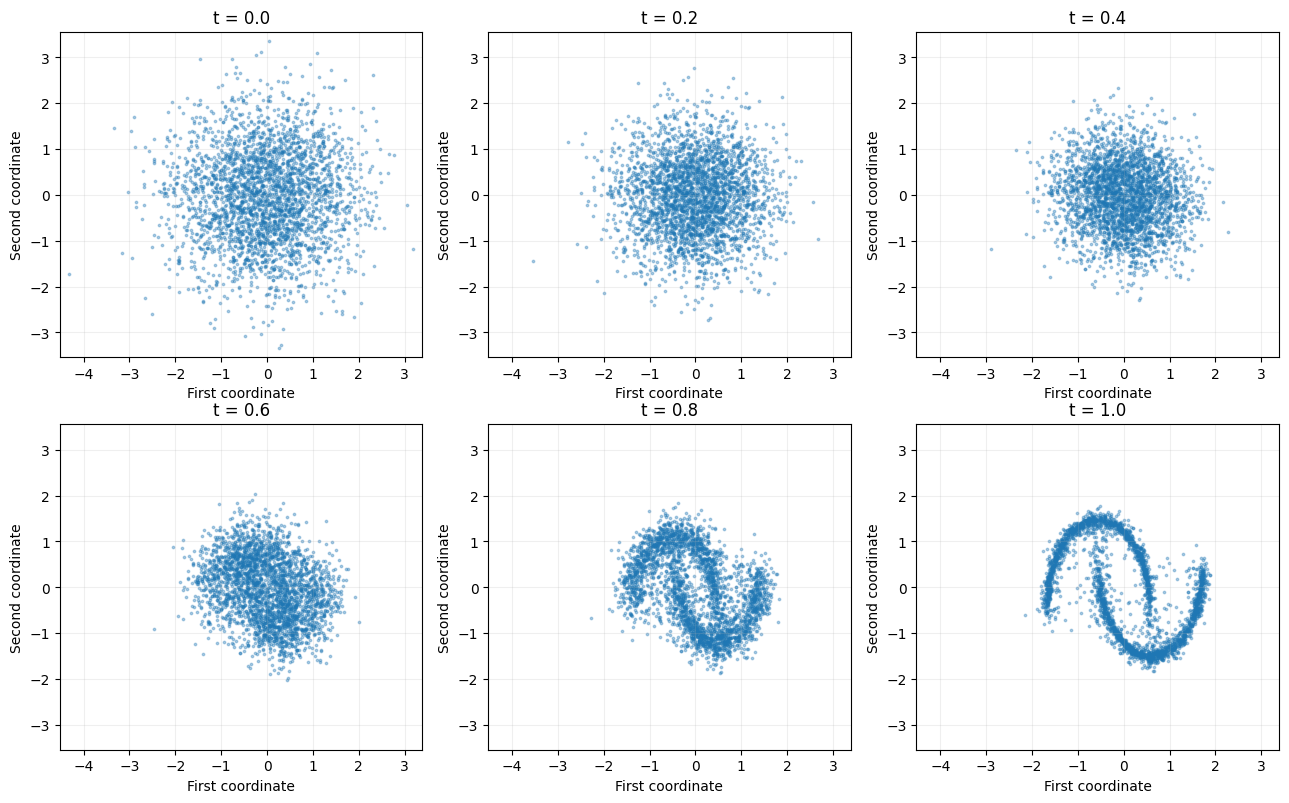

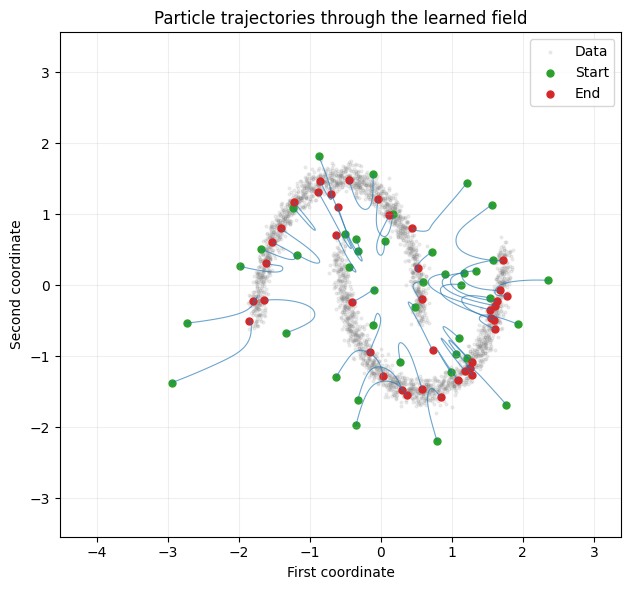

In [ ]:
import torch
import matplotlib.pyplot as plt

net = model.NN
device = next(net.parameters()).device
dtype = next(net.parameters()).dtype

n_samples = 3_000
steps = 100
h = 1.0 / steps

# Use the same initial noise for reproducible comparisons.
generator = torch.Generator(device=device).manual_seed(123)

was_training = net.training
net.eval()

with torch.no_grad():
    x = torch.randn(
        n_samples, 2,
        generator=generator,
        device=device,
        dtype=dtype,
    )

    trajectory = [x.cpu().clone()]

    for i in range(steps):
        t = torch.full(
            (n_samples, 1),
            i * h,
            device=device,
            dtype=dtype,
        )

        velocity = net(torch.cat([x, t], dim=1))
        x = x + h * velocity

        trajectory.append(x.cpu().clone())

net.train(was_training)

# Shape: (steps + 1, n_samples, 2).
trajectory = torch.stack(trajectory).numpy()
target = train_data[:n_samples].detach().cpu().numpy()

if not torch.isfinite(torch.from_numpy(trajectory)).all():
    raise ValueError("NaN or Inf encountered during sampling.")

# Use shared axis limits for consistent comparisons.
x_min = min(trajectory[..., 0].min(), target[:, 0].min())
x_max = max(trajectory[..., 0].max(), target[:, 0].max())
y_min = min(trajectory[..., 1].min(), target[:, 1].min())
y_max = max(trajectory[..., 1].max(), target[:, 1].max())

padding = 0.2


def format_axis(ax):
    ax.set_xlim(x_min - padding, x_max + padding)
    ax.set_ylim(y_min - padding, y_max + padding)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("First coordinate")
    ax.set_ylabel("Second coordinate")
    ax.grid(alpha=0.2)


# 1. Target data and generated samples.
fig, axes = plt.subplots(1, 2, figsize=(11, 5))

axes[0].scatter(
    target[:, 0], target[:, 1],
    s=4, alpha=0.4, color="tab:orange",
)
axes[0].set_title("Target distribution")

generated = trajectory[-1]

axes[1].scatter(
    generated[:, 0], generated[:, 1],
    s=4, alpha=0.4, color="tab:blue",
)
axes[1].set_title(f"Generated samples: {steps} Euler steps")

for ax in axes:
    format_axis(ax)

plt.tight_layout()
plt.show()


# 2. The same particle cloud at different times.
fig, axes = plt.subplots(2, 3, figsize=(13, 8))

for ax, step in zip(axes.flat, [0, 20, 40, 60, 80, 100]):
    points = trajectory[step]

    ax.scatter(
        points[:, 0], points[:, 1],
        s=3, alpha=0.35, color="tab:blue",
    )
    ax.set_title(f"t = {step / steps:.1f}")
    format_axis(ax)

plt.tight_layout()
plt.show()


# 3. Trajectories of 40 individual particles.
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    target[:, 0], target[:, 1],
    s=4, alpha=0.12, color="gray",
    label="Data",
)

for j in range(40):
    ax.plot(
        trajectory[:, j, 0],
        trajectory[:, j, 1],
        linewidth=0.8,
        alpha=0.65,
        color="tab:blue",
    )

ax.scatter(
    trajectory[0, :40, 0], trajectory[0, :40, 1],
    s=25, color="tab:green", label="Start",
)

ax.scatter(
    trajectory[-1, :40, 0], trajectory[-1, :40, 1],
    s=25, color="tab:red", label="End",
)

ax.set_title("Particle trajectories through the learned field")
format_axis(ax)
ax.legend()

plt.tight_layout()
plt.show()

# Score Matching Model

Используем тот же путь, что и в Flow Matching:

$$x_t = t z + (1 - t)\varepsilon,\qquad \varepsilon\sim\mathcal{N}(0, I).$$

Сеть теперь предсказывает score $s_\theta(x,t)\approx\nabla_x\log p_t(x)$.
Условный score известен: $\nabla_x\log p_t(x\mid z)=-\varepsilon/(1-t)$.
По Algorithm 4 из конспекта (стр. 31–32) обучаем её с loss

$$L_{CSM}=\mathbb{E}\left\|s_\theta(x_t,t)+\frac{\varepsilon}{1-t}\right\|^2.$$

В `fit(..., weighted=False)` реализован именно этот loss. По умолчанию
`weighted=True`: умножаем ошибку каждого примера на $(1-t)^2$, как при
перевзвешивании на стр. 32, и получаем более устойчивый вариант

$$L_{weighted}=\mathbb{E}\left\|(1-t)s_\theta(x_t,t)+\varepsilon\right\|^2.$$

Это меняет веса времён в loss; идеальный оптимальный score при каждом $t$ тот же,
но результат обучения сети с ограниченной ёмкостью может отличаться.
`MSELoss` дополнительно усредняет по координатам, то есть делит квадрат нормы на `dim`.

Для генерации переводим score в скорость по Proposition 1 (стр. 26):

$$u_\theta(x,t)=\frac{x+(1-t)s_\theta(x,t)}{t}.$$

`SMModel.sample` по умолчанию решает эту ODE методом Эйлера (`sigma=0`).
При `sigma > 0` он использует ту же SDE, что и следующий раздел.

В обеих новых моделях время идёт **от шума к данным**. Чтобы не делить на ноль,
обучаемся и интегрируем на $[\text{eps},1-\text{eps}]$, где `eps=0.01`.
Начальный $\mathcal{N}(0,I)$ здесь приближает $p_{\text{eps}}$, а конечные точки
приближают $p_{1-\text{eps}}$, то есть слегка зашумлённые данные.
Это численное приближение; уменьшение `eps` требует более точной сети и меньшего шага.

In [ ]:
from torch import nn
import torch.optim as optim

class SMNeuralNetwork(nn.Module):
  def __init__(self):
    super().__init__()

    self.linear_1 = nn.Linear(3, 128)
    self.silu_1 = nn.SiLU()
    self.linear_2 = nn.Linear(128, 128)
    self.silu_2 = nn.SiLU()
    self.linear_3 = nn.Linear(128, 128)
    self.silu_3 = nn.SiLU()
    self.linear_4 = nn.Linear(128, 2)

  def forward(self, x):
    x = self.linear_1(x)
    x = self.silu_1(x)
    x = self.linear_2(x)
    x = self.silu_2(x)
    x = self.linear_3(x)
    x = self.silu_3(x)
    x = self.linear_4(x)

    return x


class SMModel():
  def __init__(self, NN, dim, dataset, verbose=True, log_every=50, eps=0.01):
    if not 0 < eps < 0.5:
      raise ValueError("eps must be between 0 and 0.5.")
    if log_every < 1:
      raise ValueError("log_every must be positive.")

    self.NN = NN
    self.dim = dim
    self.dataset = dataset
    self.verbose = verbose
    self.log_every = log_every
    self.eps = eps
    self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  def fit(self, epochs, batch_size, learning_rate=0.001, weighted=True, denoising=False, ):

    if denoising and not hasattr(self.NN, "denoise"):
      raise ValueError("denoising=True requires a network with a denoise method.")

    self.NN.to(self.device)
    dtype = next(self.NN.parameters()).dtype

    train_loader = torch.utils.data.DataLoader(self.dataset, batch_size=batch_size, shuffle=True)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(self.NN.parameters(), lr=learning_rate)

    history = []
    for epoch in range(epochs):
      self.NN.train()
      running_loss = 0.0
      seen_samples = 0

      for inputs in train_loader:
        inputs = inputs.to(device=self.device, dtype=dtype)
        current_batch_size = inputs.shape[0]

        optimizer.zero_grad(set_to_none=True)
        epsilons = torch.randn(current_batch_size, self.dim, device=self.device, dtype=dtype)
        t = self.eps + (1 - 2 * self.eps) * torch.rand(current_batch_size, 1, device=self.device, dtype=dtype)
        z = inputs
        x = t * z + (1 - t) * epsilons
        if denoising:
          loss = criterion(self.NN.denoise(x, t), z)
        else:
          s = self.NN(torch.cat([x, t], dim=1))
          if weighted:
            loss = criterion((1 - t) * s, -epsilons)
          else:
            loss = criterion(s, -epsilons / (1 - t))
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * current_batch_size
        seen_samples += current_batch_size

      epoch_loss = running_loss / seen_samples
      history.append(epoch_loss)
      if self.verbose and (epoch == 0 or (epoch + 1) % self.log_every == 0 or epoch + 1 == epochs):
        print(
          f"Epoch {epoch + 1}/{epochs}, "
          f"loss: {epoch_loss:.6f}"
        )

    return history

  def score(self, x, t):
    return self.NN(torch.cat([x, t], dim=1))

  @torch.no_grad()
  def sample(self, steps, n_samples=1, sigma=0.0, return_trajectory=False):
    if steps < 1 or n_samples < 1:
      raise ValueError("steps and n_samples must be positive.")
    if sigma < 0:
      raise ValueError("sigma must be non-negative.")

    self.NN.to(self.device)
    self.NN.eval()

    dtype = next(self.NN.parameters()).dtype
    x = torch.randn(n_samples, self.dim, device=self.device, dtype=dtype)
    h = (1 - 2 * self.eps) / steps
    if return_trajectory:
      trajectory = [x.cpu().clone()]

    for i in range(steps):
      t = torch.full((n_samples, 1), self.eps + i * h, device=self.device, dtype=dtype)
      if hasattr(self.NN, "score_and_velocity"):
        s, u = self.NN.score_and_velocity(x, t)
      else:
        s = self.score(x, t)
        u = (x + (1 - t) * s) / t
      sigma_t = sigma * (1 - t)
      x = x + h * (u + 0.5 * sigma_t ** 2 * s)
      if sigma > 0:
        x = x + sigma_t * h ** 0.5 * torch.randn_like(x)

      if return_trajectory:
        trajectory.append(x.cpu().clone())

    if not torch.isfinite(x).all():
      raise ValueError("NaN or Inf encountered during sampling.")

    if return_trajectory:
      return x, torch.stack(trajectory)
    return x

In [ ]:
torch.manual_seed(SEED)

s = SMNeuralNetwork()

score_model = SMModel(s, 2, train_data)
score_history = score_model.fit(100, 256)

Epoch 1/100, loss: 0.597689
Epoch 50/100, loss: 0.419054
Epoch 100/100, loss: 0.406412


In [ ]:
def plot_samples(samples, trajectory, target, title, eps):
    generated = samples.detach().cpu().numpy()
    trajectory = trajectory.detach().cpu().numpy()
    target = target.detach().cpu().numpy()

    if not np.isfinite(trajectory).all():
        raise ValueError("NaN or Inf encountered during sampling.")

    x_min = min(trajectory[..., 0].min(), target[:, 0].min())
    x_max = max(trajectory[..., 0].max(), target[:, 0].max())
    y_min = min(trajectory[..., 1].min(), target[:, 1].min())
    y_max = max(trajectory[..., 1].max(), target[:, 1].max())
    padding = 0.2
    steps = len(trajectory) - 1

    def format_axis(ax):
        ax.set_xlim(x_min - padding, x_max + padding)
        ax.set_ylim(y_min - padding, y_max + padding)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("First coordinate")
        ax.set_ylabel("Second coordinate")
        ax.grid(alpha=0.2)

    # 1. Target data and generated samples.
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))

    axes[0].scatter(
        target[:, 0], target[:, 1],
        s=4, alpha=0.4, color="tab:orange",
    )
    axes[0].set_title("Target distribution")

    axes[1].scatter(
        generated[:, 0], generated[:, 1],
        s=4, alpha=0.4, color="tab:blue",
    )
    axes[1].set_title(title)

    for ax in axes:
        format_axis(ax)

    plt.tight_layout()
    plt.show()

    # 2. The same particle cloud at different times.
    fig, axes = plt.subplots(2, 3, figsize=(13, 8))

    for ax, step in zip(axes.flat, np.linspace(0, steps, 6, dtype=int)):
        points = trajectory[step]

        ax.scatter(
            points[:, 0], points[:, 1],
            s=3, alpha=0.35, color="tab:blue",
        )
        t = eps + (1 - 2 * eps) * step / steps
        ax.set_title(f"t = {t:.2f}")
        format_axis(ax)

    plt.tight_layout()
    plt.show()

    # 3. Trajectories of 40 individual particles.
    fig, ax = plt.subplots(figsize=(7, 6))

    ax.scatter(
        target[:, 0], target[:, 1],
        s=4, alpha=0.12, color="gray",
        label="Data",
    )

    for j in range(min(40, trajectory.shape[1])):
        ax.plot(
            trajectory[:, j, 0],
            trajectory[:, j, 1],
            linewidth=0.8,
            alpha=0.65,
            color="tab:blue",
        )

    ax.scatter(
        trajectory[0, :40, 0], trajectory[0, :40, 1],
        s=25, color="tab:green", label="Start",
    )

    ax.scatter(
        trajectory[-1, :40, 0], trajectory[-1, :40, 1],
        s=25, color="tab:red", label="End",
    )

    ax.set_title("Particle trajectories through the learned field")
    format_axis(ax)
    ax.legend()

    plt.tight_layout()
    plt.show()

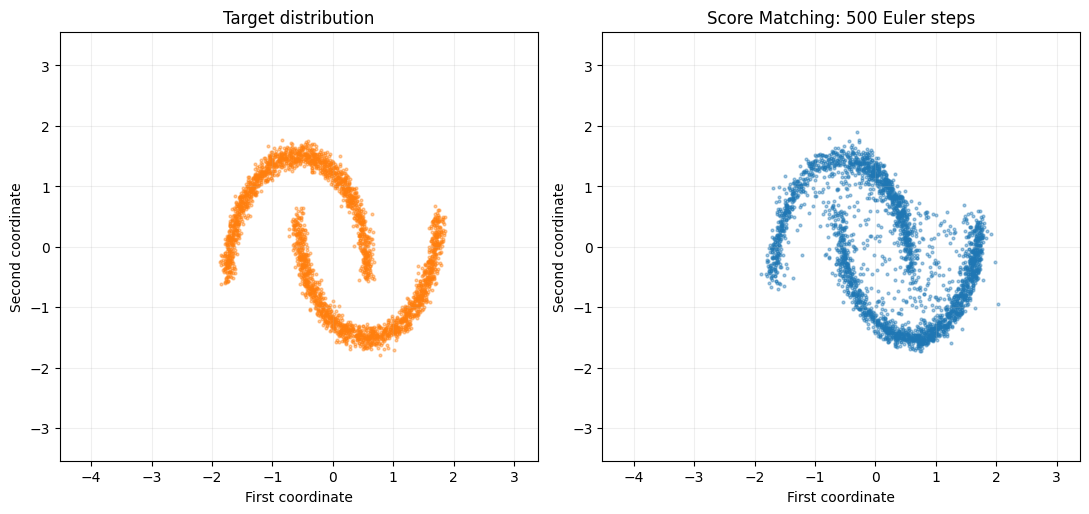

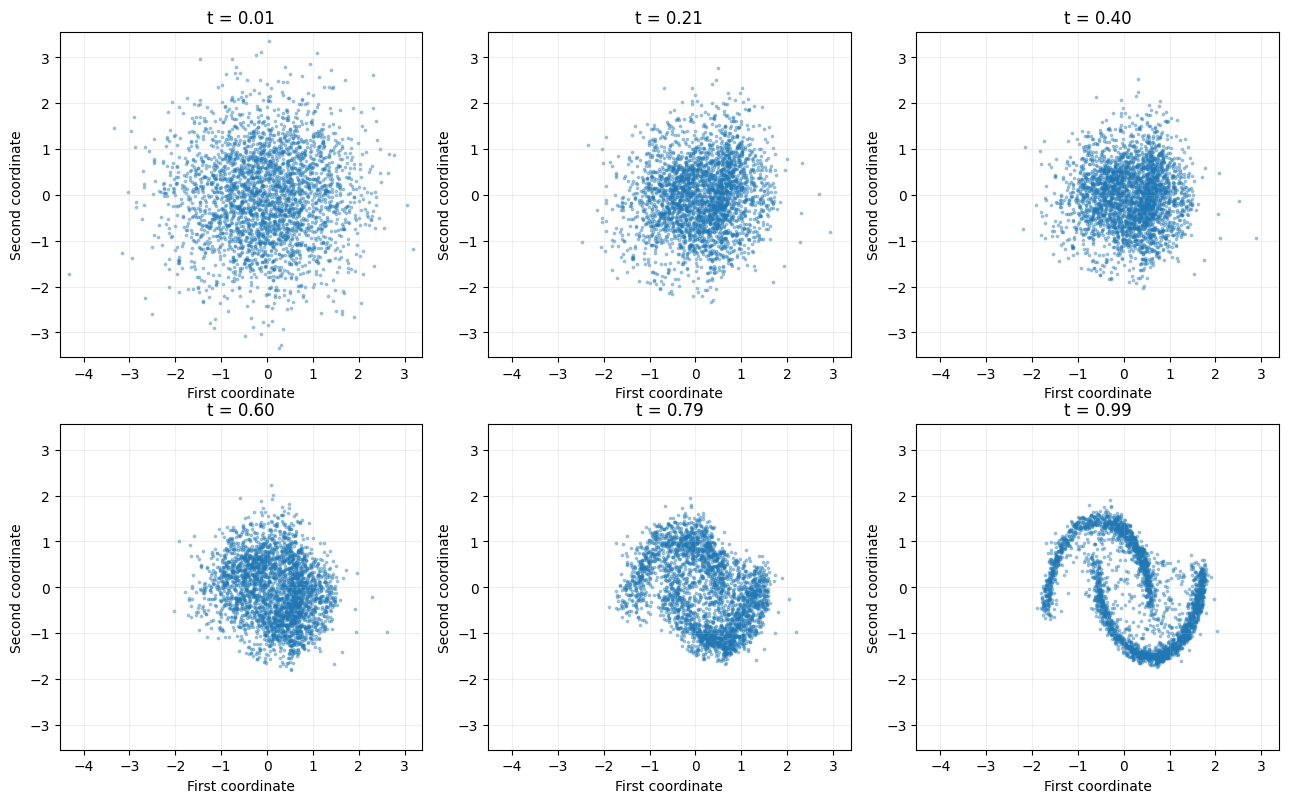

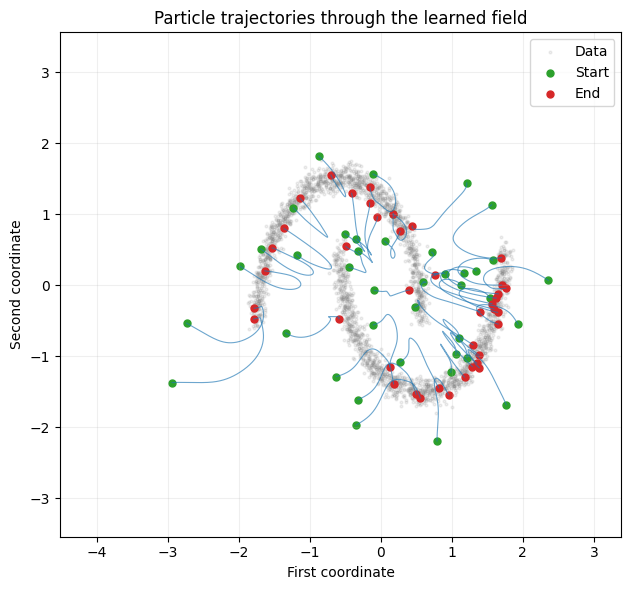

In [ ]:
torch.manual_seed(123)

score_samples, score_trajectory = score_model.sample(
    steps=500,
    n_samples=3_000,
    return_trajectory=True,
)

plot_samples(
    score_samples,
    score_trajectory,
    train_data[:3_000],
    "Score Matching: 500 Euler steps",
    score_model.eps,
)

# Diffusion Model

По Example 23 и Algorithm 4 (стр. 32) вместо score напрямую предсказываем шум:

$$L_{noise}=\mathbb{E}\|\varepsilon_\theta(x_t,t)-\varepsilon\|^2,
\qquad s_\theta(x,t)=-\frac{\varepsilon_\theta(x,t)}{1-t}.$$

Score matching и diffusion связаны: это другая параметризация того же score.
Здесь реализована непрерывная diffusion-модель из лекции, с тем же линейным
путём $x_t=tz+(1-t)\varepsilon$.

Для генерации используем SDE extension из Theorem 17 / Example 18 (стр. 28):

$$dX_t=\left[u_\theta(X_t,t)+\frac{\sigma_t^2}{2}s_\theta(X_t,t)\right]dt
+\sigma_t\,dW_t,$$

$$u_\theta(x,t)=\frac{x+(1-t)s_\theta(x,t)}{t}
=\frac{x-\varepsilon_\theta(x,t)}{t}.$$

Шаг Эйлера — Маруямы:

$$x\leftarrow x+h\left(u_\theta+\frac{\sigma_t^2}{2}s_\theta\right)
+\sigma_t\sqrt{h}\,\xi,\qquad\xi\sim\mathcal{N}(0,I).$$

Выбираем $\sigma_t=\text{sigma}\cdot(1-t)$: случайные возмущения уменьшаются
при приближении к данным. По умолчанию `sigma=1.0`; при `sigma=0` получаем ODE.
Коэффициент $1/2$, положительный знак score-поправки и множитель $\sqrt{h}$
соответствуют направлению времени в этом конспекте.

In [ ]:
from torch import nn
import torch.optim as optim

class DiffusionNeuralNetwork(nn.Module):
  def __init__(self):
    super().__init__()

    self.linear_1 = nn.Linear(3, 128)
    self.silu_1 = nn.SiLU()
    self.linear_2 = nn.Linear(128, 128)
    self.silu_2 = nn.SiLU()
    self.linear_3 = nn.Linear(128, 128)
    self.silu_3 = nn.SiLU()
    self.linear_4 = nn.Linear(128, 2)

  def forward(self, x):
    x = self.linear_1(x)
    x = self.silu_1(x)
    x = self.linear_2(x)
    x = self.silu_2(x)
    x = self.linear_3(x)
    x = self.silu_3(x)
    x = self.linear_4(x)

    return x


class DiffusionModel():
  def __init__(self, NN, dim, dataset, verbose=True, log_every=50, eps=0.01):
    if not 0 < eps < 0.5:
      raise ValueError("eps must be between 0 and 0.5.")
    if log_every < 1:
      raise ValueError("log_every must be positive.")

    self.NN = NN
    self.dim = dim
    self.dataset = dataset
    self.verbose = verbose
    self.log_every = log_every
    self.eps = eps
    self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

  def fit(self, epochs, batch_size, learning_rate=0.001, denoising=False, ):

    if denoising and not hasattr(self.NN, "denoise"):
      raise ValueError("denoising=True requires a network with a denoise method.")

    self.NN.to(self.device)
    dtype = next(self.NN.parameters()).dtype

    train_loader = torch.utils.data.DataLoader(self.dataset, batch_size=batch_size, shuffle=True)

    criterion = nn.MSELoss()
    optimizer = optim.Adam(self.NN.parameters(), lr=learning_rate)

    history = []
    for epoch in range(epochs):
      self.NN.train()
      running_loss = 0.0
      seen_samples = 0

      for inputs in train_loader:
        inputs = inputs.to(device=self.device, dtype=dtype)
        current_batch_size = inputs.shape[0]

        optimizer.zero_grad(set_to_none=True)
        epsilons = torch.randn(current_batch_size, self.dim, device=self.device, dtype=dtype)
        t = self.eps + (1 - 2 * self.eps) * torch.rand(current_batch_size, 1, device=self.device, dtype=dtype)
        z = inputs
        x = t * z + (1 - t) * epsilons
        if denoising:
          loss = criterion(self.NN.denoise(x, t), z)
        else:
          epsilons_pred = self.NN(torch.cat([x, t], dim=1))
          loss = criterion(epsilons_pred, epsilons)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * current_batch_size
        seen_samples += current_batch_size

      epoch_loss = running_loss / seen_samples
      history.append(epoch_loss)
      if self.verbose and (epoch == 0 or (epoch + 1) % self.log_every == 0 or epoch + 1 == epochs):
        print(
          f"Epoch {epoch + 1}/{epochs}, "
          f"loss: {epoch_loss:.6f}"
        )

    return history

  def score(self, x, t):
    epsilons_pred = self.NN(torch.cat([x, t], dim=1))
    return -epsilons_pred / (1 - t)

  @torch.no_grad()
  def sample(self, steps, n_samples=1, sigma=1.0, return_trajectory=False):
    if steps < 1 or n_samples < 1:
      raise ValueError("steps and n_samples must be positive.")
    if sigma < 0:
      raise ValueError("sigma must be non-negative.")

    self.NN.to(self.device)
    self.NN.eval()

    dtype = next(self.NN.parameters()).dtype
    x = torch.randn(n_samples, self.dim, device=self.device, dtype=dtype)
    h = (1 - 2 * self.eps) / steps
    if return_trajectory:
      trajectory = [x.cpu().clone()]

    for i in range(steps):
      t = torch.full((n_samples, 1), self.eps + i * h, device=self.device, dtype=dtype)
      if hasattr(self.NN, "score_and_velocity"):
        s, u = self.NN.score_and_velocity(x, t)
      else:
        s = self.score(x, t)
        u = (x + (1 - t) * s) / t
      sigma_t = sigma * (1 - t)
      x = x + h * (u + 0.5 * sigma_t ** 2 * s)
      if sigma > 0:
        x = x + sigma_t * h ** 0.5 * torch.randn_like(x)

      if return_trajectory:
        trajectory.append(x.cpu().clone())

    if not torch.isfinite(x).all():
      raise ValueError("NaN or Inf encountered during sampling.")

    if return_trajectory:
      return x, torch.stack(trajectory)
    return x

In [ ]:
torch.manual_seed(SEED)

epsilons_net = DiffusionNeuralNetwork()

diffusion_model = DiffusionModel(epsilons_net, 2, train_data)
diffusion_history = diffusion_model.fit(100, 256)

Epoch 1/100, loss: 0.630134
Epoch 50/100, loss: 0.416449
Epoch 100/100, loss: 0.406337


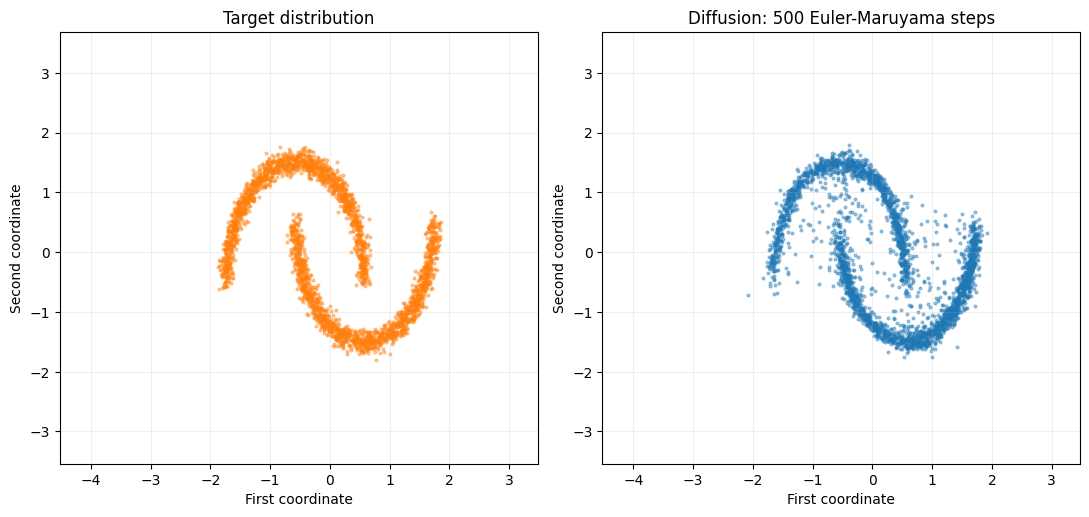

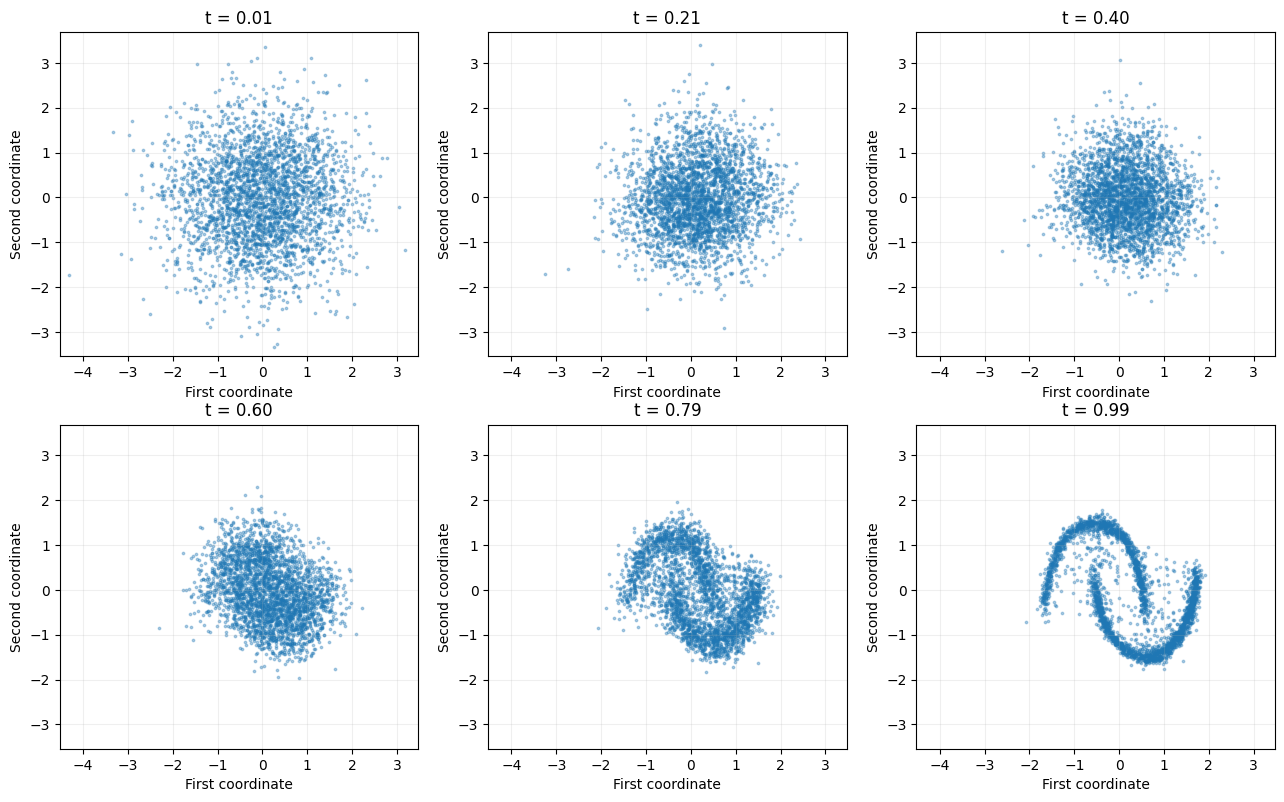

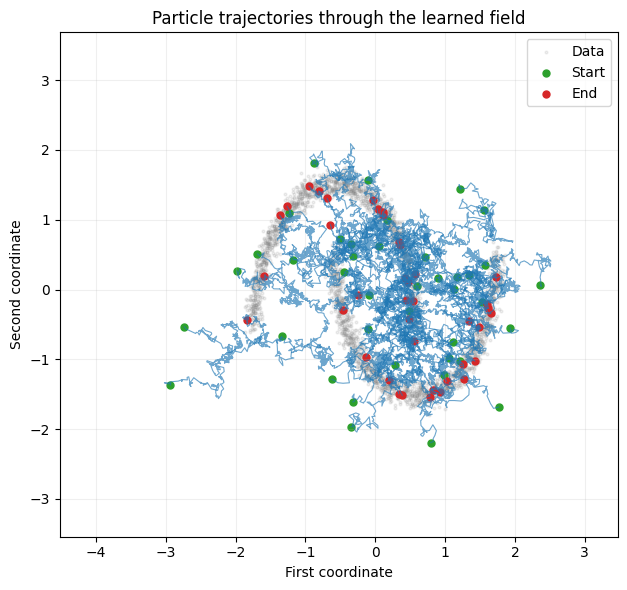

In [ ]:
torch.manual_seed(123)

diffusion_samples, diffusion_trajectory = diffusion_model.sample(
    steps=500,
    n_samples=3_000,
    sigma=1.0,
    return_trajectory=True,
)

plot_samples(
    diffusion_samples,
    diffusion_trajectory,
    train_data[:3_000],
    "Diffusion: 500 Euler-Maruyama steps",
    diffusion_model.eps,
)

## Compare the models

Сравниваем сэмплы на одинаковых осях. Графики loss показывают ход обучения;
их значения сами по себе не являются метрикой качества генерации.

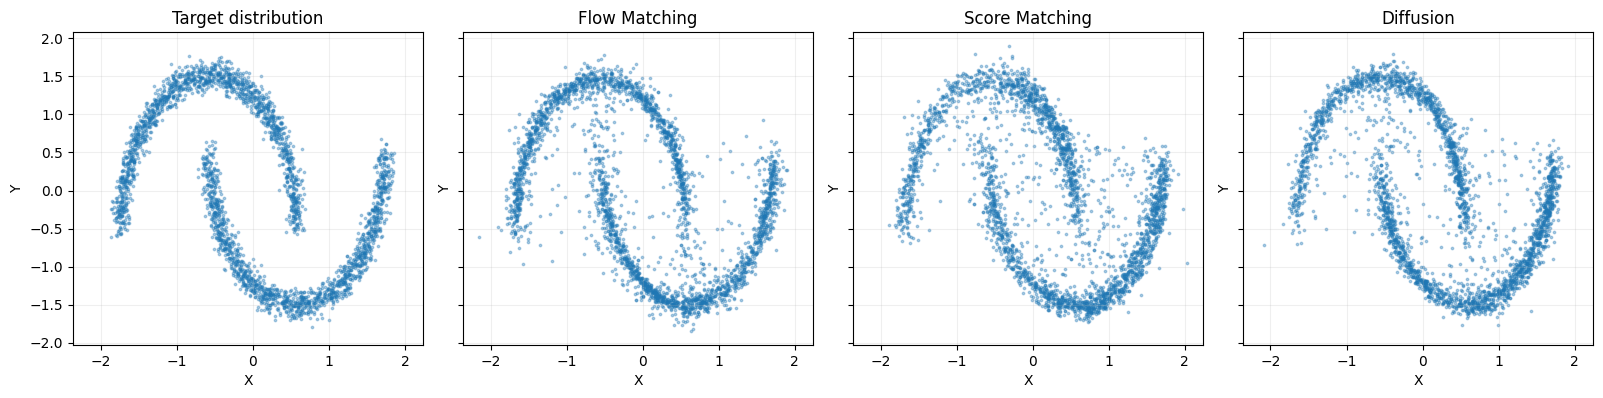

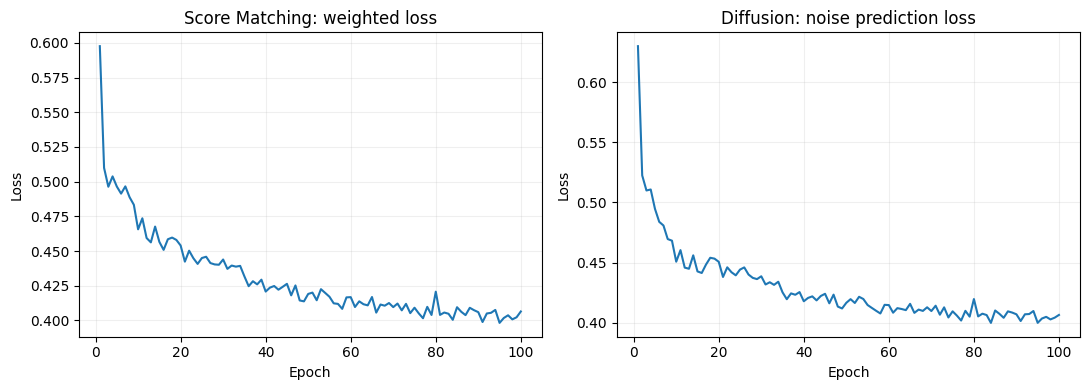

In [ ]:
torch.manual_seed(123)
fm_samples = model.sample(500, n_samples=3_000)

fig, axes = plt.subplots(
    1, 4,
    figsize=(16, 4),
    sharex=True,
    sharey=True,
)

for ax, points, title in zip(
    axes,
    [train_data[:3_000], fm_samples, score_samples, diffusion_samples],
    ["Target distribution", "Flow Matching", "Score Matching", "Diffusion"],
):
    points = points.detach().cpu().numpy()
    ax.scatter(points[:, 0], points[:, 1], s=3, alpha=0.35)
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, history, title in zip(
    axes,
    [score_history, diffusion_history],
    ["Score Matching: weighted loss", "Diffusion: noise prediction loss"],
):
    ax.plot(range(1, len(history) + 1), history)
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

# Let's experiment with mnist

**Исправление MNIST.** Старый выходной слой `Linear(512, 784)` ограничивал
предсказываемый score или шум фиксированным аффинным подпространством размерности не более 512.
Полноразмерный белый шум так убрать нельзя. При пересчёте в скорость остаток
дополнительно усиливался делением на $t$.

Сохраняем MLP, но теперь она предсказывает чистое изображение $D_\theta(x,t)$.
Из него получаем три параметризации по Remark 16 / Proposition 1 из конспекта
(стр. 26–28), для $\beta_t=1-t$:

$$u_\theta=\frac{D_\theta-x}{\beta_t},\qquad
s_\theta=\frac{tD_\theta-x}{\beta_t^2},\qquad
\varepsilon_\theta=\frac{x-tD_\theta}{\beta_t}.$$

Прямая зависимость от всех 784 компонент $x$ вычисляется явно. Узкий слой
предсказывает только структуру чистой цифры. При $t=0$ автоматически получаем
точный score начального нормального распределения: $s_\theta(x,0)=-x$.
Для сэмплирования вычисляем $u_\theta$ напрямую, без деления ошибки score на $t$.
Время подаётся через синусоидальные признаки в каждый скрытый слой.

Для MNIST используем `denoising=True`:

$$L_D=\mathbb{E}\|D_\theta(x_t,t)-z\|^2.$$

Это **другое взвешивание по времени**, а не прежний невзвешенный loss:

$$L_D=\mathbb{E}\left[\frac{\beta_t^4}{t^2}
\left\|s_\theta+\frac{\varepsilon}{\beta_t}\right\|^2\right]
=\mathbb{E}\left[\frac{\beta_t^2}{t^2}
\|\varepsilon_\theta-\varepsilon\|^2\right].$$

При фиксированном $t$ оптимум — тот же условный средний денойзер, а значит тот же
маргинальный score. В коде считаем $L_D$ напрямую, без неустойчивых дробей.
`weighted` используется только при `denoising=False`.
Функция `tanh` на выходе денойзера соответствует диапазону пикселей `[-1, 1]`.

Один обученный денойзер используется для всех трёх параметризаций: отдельное
повторное обучение при этом не требуется. Поэтому сравнение ниже показывает
разные способы сэмплирования **одних и тех же весов**.

Запусти ячейки определений `FMModel`, `SMModel`, `DiffusionModel` выше, затем этот
раздел заново. Старые MNIST-веса несовместимы с исправленной архитектурой.

In [ ]:
from torchvision.datasets import MNIST

mnist = MNIST(
  root="./data",
  train=True,
  download=True,
)

mnist_train_data = (
  mnist.data
  .reshape(-1, 28 * 28)
  .to(torch.float32)
  .div(127.5)
  .sub(1.0)
)

print("Training data shape:", mnist_train_data.shape)

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 459kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 3.66MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.61MB/s]


Training data shape: torch.Size([60000, 784])


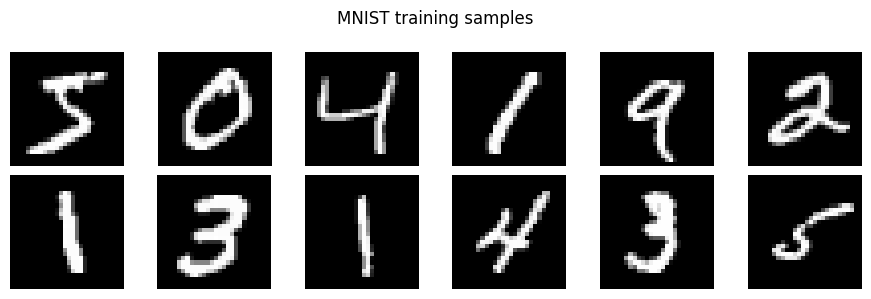

In [ ]:
fig, axes = plt.subplots(2, 6, figsize=(9, 3))

for ax, pixels in zip(axes.flat, mnist_train_data[:12]):
  ax.imshow(
      pixels.reshape(28, 28),
      cmap="gray",
      vmin=-1,
      vmax=1,
  )
  ax.axis("off")

fig.suptitle("MNIST training samples")
plt.tight_layout()
plt.show()

In [ ]:
import math
import torch
from torch import nn


class MNISTNetwork(nn.Module):
    def __init__(self):
        super().__init__()

        frequencies = torch.exp(torch.linspace(0, math.log(100), 16))
        self.register_buffer("frequencies", frequencies)
        self.time_layers = nn.Sequential(
            nn.Linear(32, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
        )
        self.linear_1 = nn.Linear(784, 512)
        self.time_1 = nn.Linear(128, 512)
        self.linear_2 = nn.Linear(512, 512)
        self.time_2 = nn.Linear(128, 512)
        self.linear_3 = nn.Linear(512, 512)
        self.time_3 = nn.Linear(128, 512)
        self.linear_4 = nn.Linear(512, 784)
        self.silu = nn.SiLU()

    def denoise(self, x, t):
        angles = t * self.frequencies[None, :]
        time = self.time_layers(torch.cat([angles.sin(), angles.cos()], dim=1))

        x = self.silu(self.linear_1(x) + self.time_1(time))
        x = self.silu(self.linear_2(x) + self.time_2(time))
        x = self.silu(self.linear_3(x) + self.time_3(time))
        return self.linear_4(x).tanh()

    def score_and_velocity(self, x, t):
        z = self.denoise(x, t)
        s = (t * z - x) / (1 - t) ** 2
        u = (z - x) / (1 - t)
        return s, u


class MNISTFlowNetwork(MNISTNetwork):
    def forward(self, x):
        t = x[:, -1:]
        z = self.denoise(x[:, :-1], t)
        return (z - x[:, :-1]) / (1 - t)


class MNISTScoreNetwork(MNISTNetwork):
    def forward(self, x):
        t = x[:, -1:]
        z = self.denoise(x[:, :-1], t)
        return (t * z - x[:, :-1]) / (1 - t) ** 2


class MNISTDiffusionNetwork(MNISTNetwork):
    def forward(self, x):
        t = x[:, -1:]
        z = self.denoise(x[:, :-1], t)
        return (x[:, :-1] - t * z) / (1 - t)

In [ ]:
from pathlib import Path

torch.manual_seed(SEED)

mnist_score_net = MNISTScoreNetwork()

mnist_score_model = SMModel(
    NN=mnist_score_net,
    dim=784,
    dataset=mnist_train_data,
    log_every=1,
)

# Upload MNISTDenoiser.pt into the Colab working directory to skip training.
checkpoint_path = Path("MNISTDenoiser.pt")

if checkpoint_path.exists():
    checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=True)
    mnist_score_net.load_state_dict(checkpoint["state_dict"])
    mnist_score_history = checkpoint["history"]
    print(f"Loaded MNIST denoiser: {checkpoint['epochs']} epochs")
else:
    mnist_score_history = mnist_score_model.fit(
        epochs=20,
        batch_size=256,
        learning_rate=1e-3,
        denoising=True,
    )
    torch.save(
        {
            "state_dict": {key: value.detach().cpu() for key, value in mnist_score_net.state_dict().items()},
            "history": mnist_score_history,
            "epochs": 20,
        },
        checkpoint_path,
    )

Epoch 1/20, loss: 0.197878


In [ ]:
mnist_net = MNISTFlowNetwork()
mnist_net.load_state_dict(mnist_score_net.state_dict())

mnist_model = FMModel(
    NN=mnist_net,
    dim=784,
    dataset=mnist_train_data,
)

mnist_diffusion_net = MNISTDiffusionNetwork()
mnist_diffusion_net.load_state_dict(mnist_score_net.state_dict())

mnist_diffusion_model = DiffusionModel(
    NN=mnist_diffusion_net,
    dim=784,
    dataset=mnist_train_data,
    log_every=1,
)

print("Flow, score and noise networks use the same trained denoiser.")

Flow, score and noise networks use the same trained denoiser.


In [ ]:
torch.manual_seed(123)
mnist_fm_samples = mnist_model.sample(200, n_samples=24)

torch.manual_seed(123)
mnist_score_samples = mnist_score_model.sample(200, n_samples=24)

torch.manual_seed(123)
mnist_diffusion_samples = mnist_diffusion_model.sample(200, n_samples=24, sigma=1.0)

fig, axes = plt.subplots(6, 12, figsize=(14, 7))

for rows, samples, title in zip(
    [axes[:2], axes[2:4], axes[4:]],
    [mnist_fm_samples, mnist_score_samples, mnist_diffusion_samples],
    ["Flow ODE", "Score ODE", "Diffusion SDE"],
):
    if not torch.isfinite(samples).all():
        raise ValueError("NaN or Inf encountered during sampling.")

    print(
        f"{title}: min={samples.min().item():.3f}, "
        f"max={samples.max().item():.3f}"
    )

    for ax, pixels in zip(rows.flat, samples.detach().cpu()):
        ax.imshow(
            pixels.reshape(28, 28),
            cmap="gray",
            vmin=-1,
            vmax=1,
        )
        ax.axis("off")
    rows[0, 0].set_title(title, loc="left", fontsize=10)

fig.suptitle("Generated MNIST samples: one trained denoiser, three samplers")
plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(range(1, len(mnist_score_history) + 1), mnist_score_history)
ax.set_title("MNIST: denoising loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE")
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

## Проверка исправления

Денойзер обучен **20 эпох на всех 60 000 тренировочных изображениях MNIST**.
MSE уменьшилась с 0.19846 до 0.09124. В этом ноутбуке загружены полученные веса
`MNISTDenoiser.pt` и выполнены ячейки генерации: 24 примера для каждого способа,
200 шагов. Все три параметризации используют одни обученные веса.

Первую эпоху отдельно воспроизвели через `SMModel.fit(..., denoising=True)`
и `DiffusionModel.fit(..., denoising=True)`: loss и обновлённые параметры совпали.
Проверены формулы пересчёта score / velocity / noise и точное условие
$s_\theta(x,0)=-x$. Получены конечные значения пикселей без взрыва амплитуды.

Сгенерированные изображения показаны выше без отбора удачных примеров,
с фиксированным seed=123. Часть цифр ещё деформирована: это учебная MLP,
а не утверждение о высоком качестве генерации.